
# Machine Learning para Predição de Obesidade

### Objetivo

Desenvolver um modelo de Machine Learning para auxiliar profissionais de saúde na previsão de obesidade utilizando hábitos alimentares, estilo de vida e características físicas.



### Dicionário de Dados

| Coluna | Descrição |
|---|---|
| Gender | Gênero |
| Age | Idade |
| Height | Altura em metros |
| Weight | Peso em kg |
| family_history | Algum membro da família sofreu ou sofre de excesso de peso |
| FAVC | Consome alimentos altamente calóricos com frequência |
| FCVC | Frequência de consumo de vegetais |
| NCP | Número de refeições principais por dia |
| CAEC | Consumo de alimentos entre refeições |
| SMOKE | Fumante |
| CH2O | Quantidade de água ingerida diariamente |
| SCC | Monitora calorias ingeridas |
| FAF | Frequência de atividade física |
| TER | Tempo de uso de dispositivos tecnológicos |
| CALC | Frequência de consumo de álcool |
| MTRANS | Meio de transporte utilizado |
| Obesity_level | Nível de obesidade (target) |


### Bibliotecas

In [72]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Carregamento e Overview da Base

In [73]:
df = pd.read_csv('Obesity.csv')

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [74]:
print('Quantidade de linhas e colunas:')
print(df.shape)

print('\nTipos das variáveis:')
print(df.dtypes)

print('\nValores nulos:')
print(df.isnull().sum())

Quantidade de linhas e colunas:
(2111, 17)

Tipos das variáveis:
Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC              float64
NCP               float64
CAEC               object
SMOKE              object
CH2O              float64
SCC                object
FAF               float64
TUE               float64
CALC               object
MTRANS             object
Obesity            object
dtype: object

Valores nulos:
Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64


### Análise Exploratória de Dados

In [75]:
# Ordem nível de obesidade

map_ordem = {
    'Insufficient_Weight': 1,
    'Normal_Weight': 2,
    'Overweight_Level_I': 3,
    'Overweight_Level_II': 4,
    'Obesity_Type_I': 5,
    'Obesity_Type_II': 6,
    'Obesity_Type_III': 7
}

df['ordem_obesidade'] = df['Obesity'].map(map_ordem)

In [76]:
# Criando variável binária

df['obeso'] = np.where(
    df['Obesity'].isin([
        'Obesity_Type_I',
        'Obesity_Type_II',
        'Obesity_Type_III'
    ]),
    1,
    0
)

In [77]:
# Criando coluna de IMC (Índice de Massa Corporal)

df['IMC'] = df['Weight'] / (df['Height'] ** 2)

C:\Users\super\AppData\Local\Temp\ipykernel_28124\569272286.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\super\AppData\Local\Temp\ipykernel_28124\569272286.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


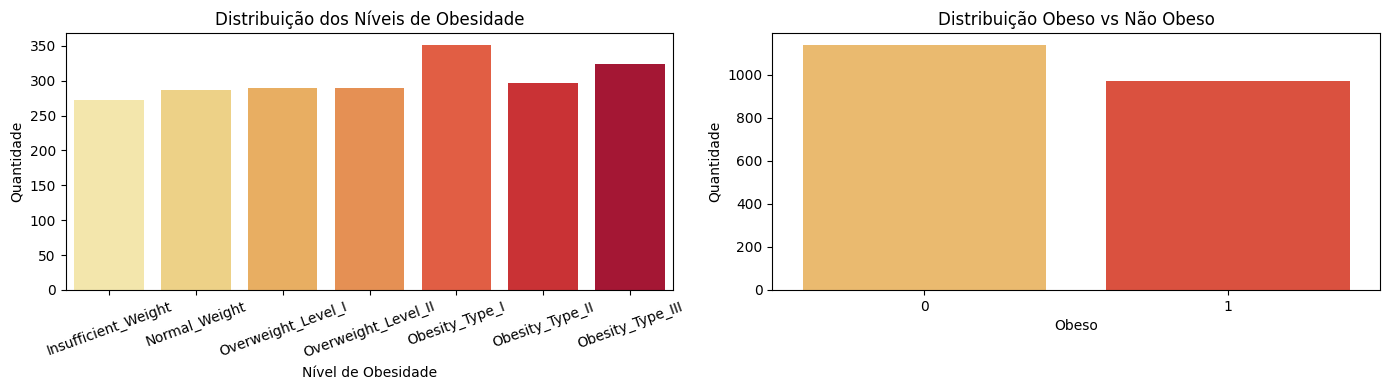

Análise: Os níveis estão relativamente balanceados


In [78]:
# Distribuição da variável target

count_obesity = (
    df.groupby(['Obesity', 'ordem_obesidade'])
    .size()
    .reset_index(name='quantidade')
    .sort_values('ordem_obesidade')
)

count_obeso = (
    df.groupby(['obeso'])
    .size()
    .reset_index(name='quantidade')
)

# Criando figura com 2 gráficos

fig, axes = plt.subplots(1, 2, figsize=(14,4))

# Gráfico 1

sns.barplot(
    data=count_obesity,
    x='Obesity',
    y='quantidade',
    palette='YlOrRd',
    ax=axes[0]
)

axes[0].set_title('Distribuição dos Níveis de Obesidade')

axes[0].set_xlabel('Nível de Obesidade')

axes[0].set_ylabel('Quantidade')

axes[0].tick_params(axis='x', rotation=20)

# Gráfico 2

sns.barplot(
    data=count_obeso,
    x='obeso',
    y='quantidade',
    palette='YlOrRd',
    ax=axes[1]
)

axes[1].set_title('Distribuição Obeso vs Não Obeso')

axes[1].set_xlabel('Obeso')

axes[1].set_ylabel('Quantidade')

# Ajustes finais

plt.tight_layout()

plt.show()

print('Análise: Os níveis estão relativamente balanceados')

C:\Users\super\AppData\Local\Temp\ipykernel_28124\600334798.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


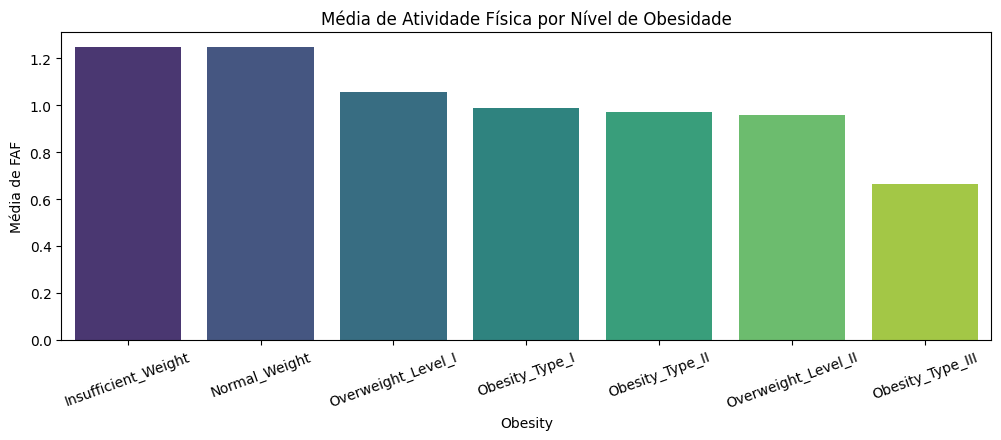

Análise: Pessoas com maior frequência de atividade física tendem a apresentar menores níveis de obesidade.


In [79]:
# Relação Obesidade vs Atividade Física

faf_mean = (
    df.groupby('Obesity')['FAF']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Gráfico
plt.figure(figsize=(12,4))

sns.barplot(
    data=faf_mean,
    x='Obesity',
    y='FAF',
    palette='viridis'
)

plt.xticks(rotation=20)

plt.title('Média de Atividade Física por Nível de Obesidade')

plt.ylabel('Média de FAF')

plt.show()

print('Análise: Pessoas com maior frequência de atividade física tendem a apresentar menores níveis de obesidade.')


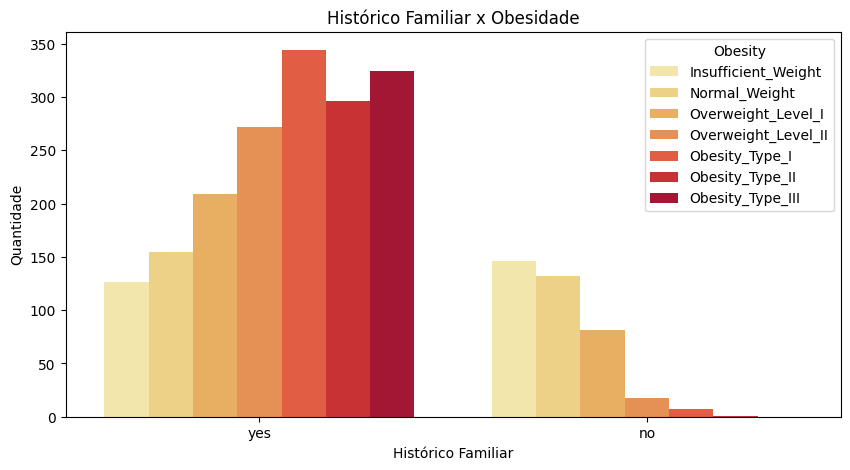

Análise: Pacientes com histórico familiar de obesidade possuem maior concentração nos níveis mais elevados de obesidade


In [80]:
# Relação Obesidade vs Histórico familiar

ordem_obesidade = (
    df[['Obesity', 'ordem_obesidade']]
    .drop_duplicates()
    .sort_values('ordem_obesidade')
)['Obesity']

# Gráfico

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='family_history',
    hue='Obesity',
    hue_order=ordem_obesidade,
    palette='YlOrRd'
)

plt.title('Histórico Familiar x Obesidade')

plt.xlabel('Histórico Familiar')

plt.ylabel('Quantidade')

plt.show()

print('Análise: Pacientes com histórico familiar de obesidade possuem maior concentração nos níveis mais elevados de obesidade')


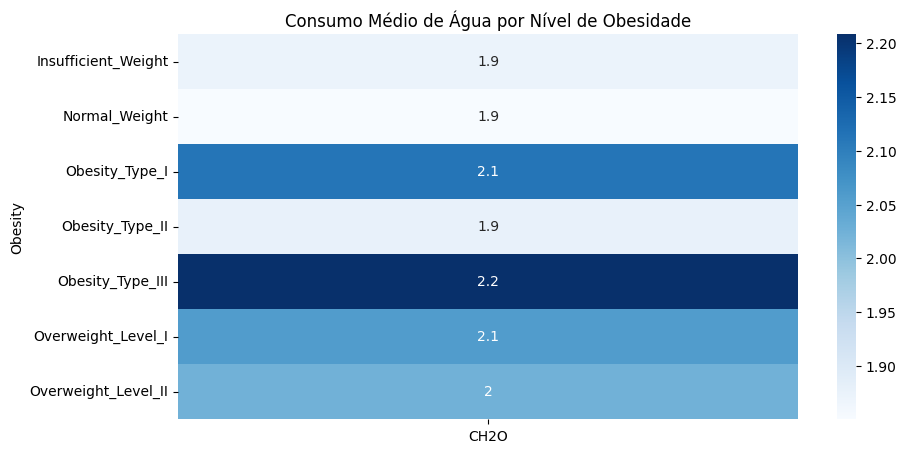

Análise: Consumo de água médio não se altera muito com o nível de obesidade


In [81]:
# Relação Obesidade vs Consumo de água

water_mean = df.groupby('Obesity')['CH2O'].mean().reset_index()

plt.figure(figsize=(10,5))

sns.heatmap(
    water_mean.set_index('Obesity'),
    annot=True,
    cmap='Blues'
)

plt.title('Consumo Médio de Água por Nível de Obesidade')

plt.show()

print('Análise: Consumo de água médio não se altera muito com o nível de obesidade')

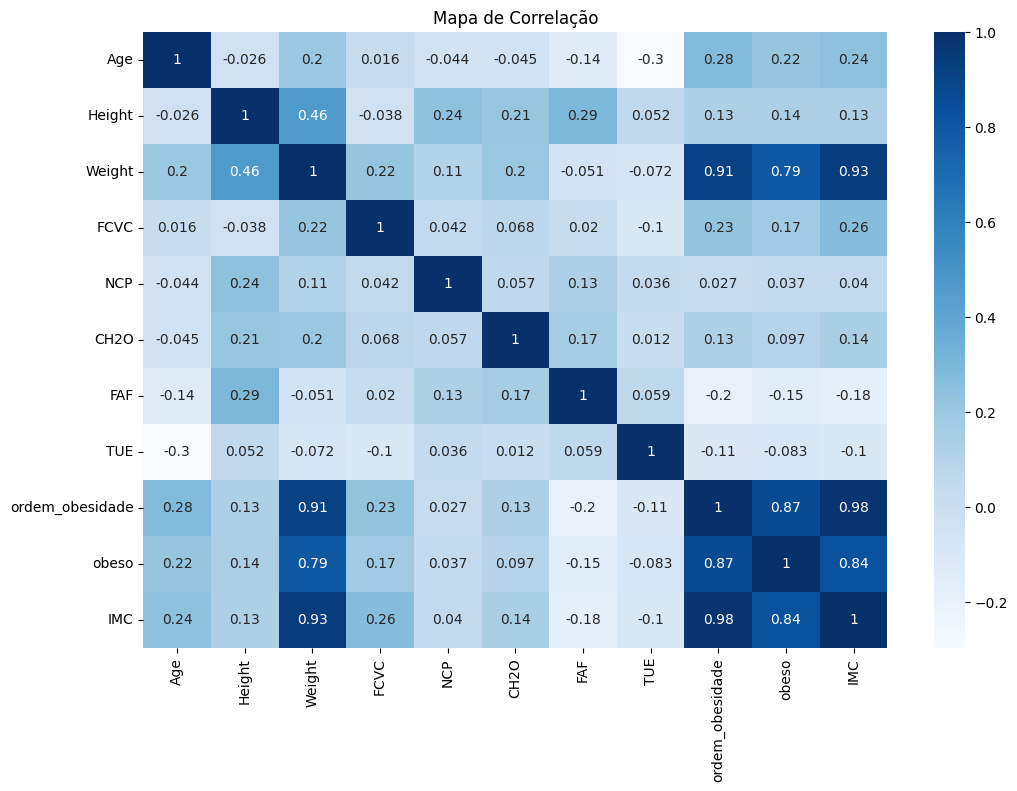

In [82]:
# Correlação entre variáveis numéricas

num_cols_corr = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))

sns.heatmap(
    num_cols_corr.corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Mapa de Correlação')

plt.show()


Análise:

- Peso e IMC tem forte correlação com o nível de obesidade
- Idade, Frequência que consome vegetais (FCVC) e Altura possuem correlação moderada positiva
- Frequência de Atividade Física (FAF) possui correlação negativa moderada com a obesidade

### Pipeline Machine Learning

In [83]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,ordem_obesidade,obeso,IMC
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,2,0,24.386526
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,2,0,24.238227
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,2,0,23.765432
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,3,0,26.851852
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,4,0,28.342381


In [84]:
# Separando features e target
X = df.drop(columns=['Obesity', 'obeso', 'ordem_obesidade'])
y = df['obeso']

# FCVC: converter para inteiro
X['FCVC'] = X['FCVC'].round().astype(int)

# CAEC e CALC: binarizar (no = 0, qualquer outro valor = 1)
X['CAEC'] = X['CAEC'].apply(lambda x: 0 if x == 'no' else 1)
X['CALC'] = X['CALC'].apply(lambda x: 0 if x == 'no' else 1)

X.head()


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,IMC
0,Female,21.0,1.62,64.0,yes,no,2,3.0,1,no,2.0,no,0.0,1.0,0,Public_Transportation,24.386526
1,Female,21.0,1.52,56.0,yes,no,3,3.0,1,yes,3.0,yes,3.0,0.0,1,Public_Transportation,24.238227
2,Male,23.0,1.80,77.0,yes,no,2,3.0,1,no,2.0,no,2.0,1.0,1,Public_Transportation,23.765432
3,Male,27.0,1.80,87.0,no,no,3,3.0,1,no,2.0,no,2.0,0.0,1,Walking,26.851852
4,Male,22.0,1.78,89.8,no,no,2,1.0,1,no,2.0,no,0.0,0.0,1,Public_Transportation,28.342381


In [85]:
# Drop das colunas Height, Weight e IMC antes da padronização
X = X.drop(columns=['Height', 'Weight', 'IMC'])

# Colunas numéricas restantes que entrarão na padronização
num_cols_originais = X.select_dtypes(exclude='object').columns
print('Colunas numéricas para padronização:')
print(num_cols_originais)


Colunas numéricas para padronização:
Index(['Age', 'FCVC', 'NCP', 'CAEC', 'CH2O', 'FAF', 'TUE', 'CALC'], dtype='object')


In [86]:
# Padronizar as variáveis numéricas com StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[num_cols_originais] = scaler.fit_transform(X[num_cols_originais])
X.head()


,Gender,Age,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Female,-0.522124,yes,no,-0.725454,0.404153,0.157344,no,-0.013073,no,-1.188039,0.561997,-1.517761,Public_Transportation
1,Female,-0.522124,yes,no,0.987559,0.404153,0.157344,yes,1.618759,yes,2.339750,-1.080625,0.658865,Public_Transportation
2,Male,-0.206889,yes,no,-0.725454,0.404153,0.157344,no,-0.013073,no,1.163820,0.561997,0.658865,Public_Transportation
3,Male,0.423582,no,no,0.987559,0.404153,0.157344,no,-0.013073,no,1.163820,-1.080625,0.658865,Walking
4,Male,-0.364507,no,no,-0.725454,-2.167023,0.157344,no,-0.013073,no,-1.188039,-1.080625,0.658865,Public_Transportation


In [87]:
# Encoding das variáveis categóricas binárias
X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})

binary_cols = ['family_history', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    X[col] = X[col].map({'yes': 1, 'no': 0})

X.head()


,Gender,Age,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,0,-0.522124,1,0,-0.725454,0.404153,0.157344,0,-0.013073,0,-1.188039,0.561997,-1.517761,Public_Transportation
1,0,-0.522124,1,0,0.987559,0.404153,0.157344,1,1.618759,1,2.339750,-1.080625,0.658865,Public_Transportation
2,1,-0.206889,1,0,-0.725454,0.404153,0.157344,0,-0.013073,0,1.163820,0.561997,0.658865,Public_Transportation
3,1,0.423582,0,0,0.987559,0.404153,0.157344,0,-0.013073,0,1.163820,-1.080625,0.658865,Walking
4,1,-0.364507,0,0,-0.725454,-2.167023,0.157344,0,-0.013073,0,-1.188039,-1.080625,0.658865,Public_Transportation


In [88]:
# One-Hot Encoding de MTRANS
X = pd.get_dummies(X, columns=['MTRANS'], drop_first=True, dtype=int)
X.head()


,Gender,Age,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,-0.522124,1,0,-0.725454,0.404153,0.157344,0,-0.013073,0,-1.188039,0.561997,-1.517761,0,0,1,0
1,0,-0.522124,1,0,0.987559,0.404153,0.157344,1,1.618759,1,2.339750,-1.080625,0.658865,0,0,1,0
2,1,-0.206889,1,0,-0.725454,0.404153,0.157344,0,-0.013073,0,1.163820,0.561997,0.658865,0,0,1,0
3,1,0.423582,0,0,0.987559,0.404153,0.157344,0,-0.013073,0,1.163820,-1.080625,0.658865,0,0,0,1
4,1,-0.364507,0,0,-0.725454,-2.167023,0.157344,0,-0.013073,0,-1.188039,-1.080625,0.658865,0,0,1,0


In [89]:
# Verificação do dataset após todos os tratamentos
# FCVC já está como inteiro, CAEC e CALC já estão binarizados (0/1)
print('Shape:', X.shape)
print('\nTipos das colunas:')
print(X.dtypes)
X.head()


Shape: (2111, 17)

Tipos das colunas:
Gender                            int64
Age                             float64
family_history                    int64
FAVC                              int64
FCVC                            float64
NCP                             float64
CAEC                            float64
SMOKE                             int64
CH2O                            float64
SCC                               int64
FAF                             float64
TUE                             float64
CALC                            float64
MTRANS_Bike                       int64
MTRANS_Motorbike                  int64
MTRANS_Public_Transportation      int64
MTRANS_Walking                    int64
dtype: object


,Gender,Age,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,-0.522124,1,0,-0.725454,0.404153,0.157344,0,-0.013073,0,-1.188039,0.561997,-1.517761,0,0,1,0
1,0,-0.522124,1,0,0.987559,0.404153,0.157344,1,1.618759,1,2.339750,-1.080625,0.658865,0,0,1,0
2,1,-0.206889,1,0,-0.725454,0.404153,0.157344,0,-0.013073,0,1.163820,0.561997,0.658865,0,0,1,0
3,1,0.423582,0,0,0.987559,0.404153,0.157344,0,-0.013073,0,1.163820,-1.080625,0.658865,0,0,0,1
4,1,-0.364507,0,0,-0.725454,-2.167023,0.157344,0,-0.013073,0,-1.188039,-1.080625,0.658865,0,0,1,0


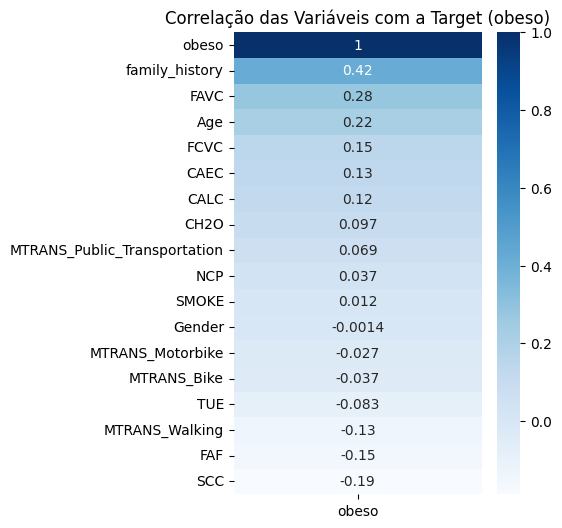

In [90]:
# Matriz de Correlação entre variáveis numéricas com a variável target
df_corr = X.copy()
df_corr['obeso'] = y

plt.figure(figsize=(4, 6))
sns.heatmap(
    df_corr.corr()[['obeso']].sort_values('obeso', ascending=False),
    annot=True,
    cmap='Blues'
)
plt.title('Correlação das Variáveis com a Target (obeso)')
plt.show()


In [91]:
# Confirmação: Height, Weight e IMC já foram removidos antes da padronização
print('Colunas no dataset final:')
print(list(X.columns))


Colunas no dataset final:
['Gender', 'Age', 'family_history', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


### Separação Treino/Teste

In [92]:
# Separar dados em 20% para teste e 80% para treino

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (1688, 17)
Teste: (423, 17)


In [93]:
# Bibliotecas necessárias para o Pipeline e Avaliação

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Modelo Random Forest Classifier

Porque o Random Forest?

- Consegue lidar com variáveis de diferentes tipos
    - contínuas ("Age", "CH2O", "FAF"), 
    - binárias ("family_history", "FAVC", "CAEC", "CALC", "FCVC", "SCC")
    - categóricas(transformadas usando o One-Hot Encoding "MTRANS")

- Consegue modelar com relações não lineares
    - Ex: Histórico Familiar, Atividade Física, Consumo de Álcool

- Geralmente não precisa ajustar tanto os hiperparâmetros

- Possível também extrair a importância das features depois

In [94]:
# Instanciando o modelo RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

print(model)

RandomForestClassifier(n_estimators=200, random_state=42)


### Treinamento do Modelo

In [95]:
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Predições

In [96]:
preds = model.predict(X_test)

### Avaliação do Modelo

In [97]:
# Accuracy (proporção de acertos sobre o total de amostras)

acc = accuracy_score(y_test, preds)

print(f'Accuracy no conjunto de teste: {acc:.4f} ({acc*100:.2f}%)')

Accuracy no conjunto de teste: 0.9220 (92.20%)


In [98]:
# Classification Report

# Precision (dos que o modelo disse ser obeso, quantos realmente eram?)
#   → Mede falsos positivos

# Recall (dos que realmente eram obesos, quantos o modelo encontrou?)

# F1-Score (média entre Precision e Recall)

# Support (quantidade de amostras reais de cada classe no teste)

print('Classification Report:')
print(' ' * 50)
print(classification_report(y_test, preds, target_names=['Não Obeso (0)', 'Obeso (1)']))


Classification Report:
                                                  
               precision    recall  f1-score   support

Não Obeso (0)       0.93      0.93      0.93       228
    Obeso (1)       0.92      0.91      0.92       195

     accuracy                           0.92       423
    macro avg       0.92      0.92      0.92       423
 weighted avg       0.92      0.92      0.92       423



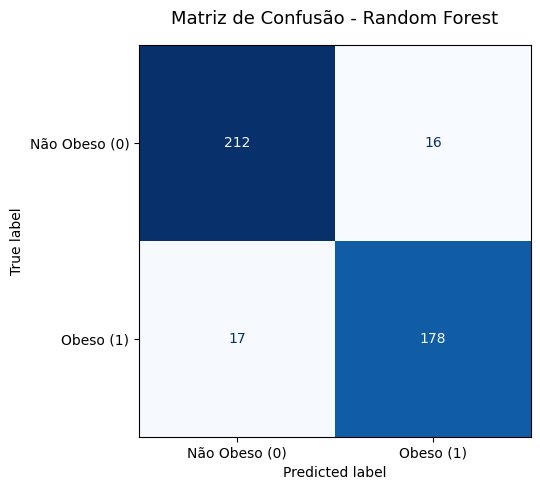

Verdadeiros Negativos (TN): 212
Falsos Positivos    (FP): 16
Falsos Negativos    (FN): 17  ← pacientes obesos não identificados
Verdadeiros Positivos (TP): 178


In [99]:
# Matriz de Confusão

cm = confusion_matrix(y_test, preds)

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Não Obeso (0)', 'Obeso (1)']
).plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title('Matriz de Confusão - Random Forest', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdadeiros Negativos (TN): {tn}')
print(f'Falsos Positivos    (FP): {fp}')
print(f'Falsos Negativos    (FN): {fn}  ← pacientes obesos não identificados')
print(f'Verdadeiros Positivos (TP): {tp}')


### Importância das Variáveis - Random Forest

In [100]:
# Extraindo importâncias do modelo treinado

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False).reset_index(drop=True)

print('Top 10 variáveis mais importantes:')
feat_imp.head(10)


Top 10 variáveis mais importantes:


,feature,importance
0,Age,0.190284
1,family_history,0.128461
2,NCP,0.124336
3,FAF,0.122870
4,CH2O,0.116764
5,TUE,0.107506
6,FAVC,0.049968
7,FCVC,0.041203
8,Gender,0.034960
9,CALC,0.028763


C:\Users\super\AppData\Local\Temp\ipykernel_28124\592098068.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


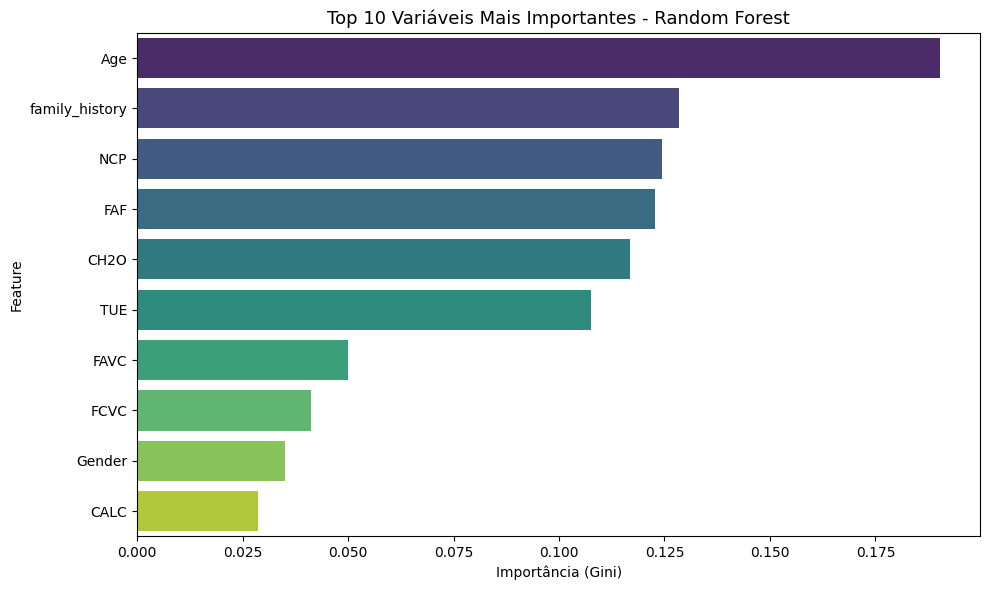

In [101]:
# Gráfico 

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feat_imp.head(10),
    x='importance',
    y='feature',
    palette='viridis'
)

plt.title('Top 10 Variáveis Mais Importantes - Random Forest', fontsize=13)
plt.xlabel('Importância (Gini)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Curva ROC e AUC

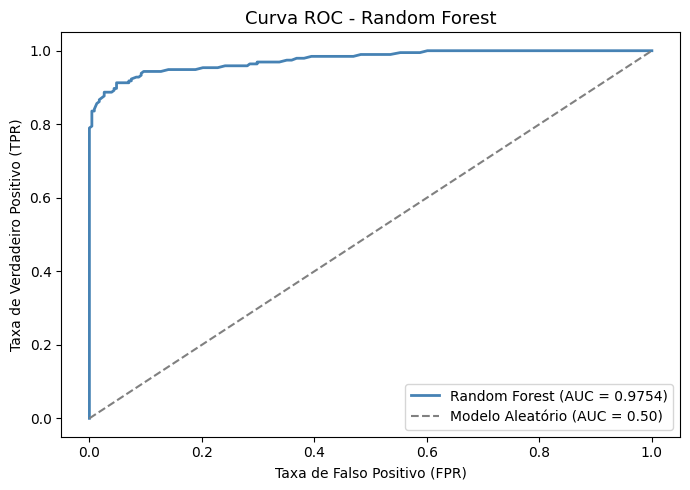

AUC-ROC: 0.9754


In [102]:
# Curva ROC

from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades da classe positiva (obeso = 1)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculando a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Gráfico
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Modelo Aleatório (AUC = 0.50)')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva ROC - Random Forest', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'AUC-ROC: {auc:.4f}')


### Validação Cruzada

In [103]:
# Validação Cruzada com StratifiedKFold

# A divisão treino/teste simples pode ser afetada pelo acaso. A validação cruzada divide os dados em K partes (folds), treina em K-1 e testa em 1, rodando K vezes.

# StratifiedKFold garante que cada fold mantenha a proporção das classes (obeso vs. não obeso)

from sklearn.model_selection import cross_val_score, StratifiedKFold

# Validação cruzada com StratifiedKFold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Executando a validação cruzada (treinando sobre X completo para CV)
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X,
    y,
    cv=cv_strategy,
    scoring='accuracy'
)

print('Accuracy por fold:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')

print(f'\nMédia: {cv_scores.mean():.4f}')
print(f'Desvio padrão: {cv_scores.std():.4f}')
print(f'\nAnálise: O modelo mantém performance consistente entre os folds,')
print(f'indicando que não há overfitting significativo.')


Accuracy por fold:
  Fold 1: 0.9456
  Fold 2: 0.9218
  Fold 3: 0.9194
  Fold 4: 0.9360
  Fold 5: 0.9289

Média: 0.9304
Desvio padrão: 0.0096

Análise: O modelo mantém performance consistente entre os folds,
indicando que não há overfitting significativo.


---

## Exportar Modelo


In [104]:
#Salvar modelo
import joblib
import json

# Salvar modelo treinado
joblib.dump(model, 'model_obesidade.pkl')

# Salvar scaler
joblib.dump(scaler, 'scaler_obesidade.pkl')

# Salvar nomes das colunas numéricas originais e das features finais
cols_info = {
    'num_cols_originais': list(num_cols_originais),
    'feature_cols': list(X_train.columns)
}
with open('cols_obesidade.json', 'w') as f:
    json.dump(cols_info, f)



### Como executar

```bash
pip install streamlit scikit-learn pandas numpy matplotlib seaborn joblib
streamlit run app_obesidade.py
```


In [105]:
# Requerimentos
requirements = """streamlit>=1.32.0
pandas>=2.0.0
numpy>=1.26.0
matplotlib>=3.8.0
seaborn>=0.13.0
scikit-learn>=1.4.0
joblib>=1.3.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print('requirements.txt executado')
print(requirements)


requirements.txt executado
streamlit>=1.32.0
pandas>=2.0.0
numpy>=1.26.0
matplotlib>=3.8.0
seaborn>=0.13.0
scikit-learn>=1.4.0
joblib>=1.3.0



### Código do App Streamlit

Execute a célula abaixo para criar o arquivo `app_obesidade.py`:

In [ ]:
%%writefile app_obesidade.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Configuração da página
st.set_page_config(
    page_title="Predição de Obesidade",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded",
)

# Estilos globais
st.markdown("""
<style>
    [data-testid="stAppViewContainer"] {background: #f7f9fc;}
    [data-testid="stMain"] {background: #f7f9fc;}

    [data-testid="stSidebar"] {background: #1e2a3a;}
    [data-testid="stSidebar"] * {color: #e8edf3 !important;}

    [data-testid="stMain"] p,
    [data-testid="stMain"] span,
    [data-testid="stMain"] label,
    [data-testid="stMain"] div,
    [data-testid="stMain"] h1,
    [data-testid="stMain"] h2,
    [data-testid="stMain"] h3 {
        color: #1e2a3a;
    }

    .stSelectbox label,
    .stNumberInput label,
    .stSlider label,
    .stTextInput label,
    [data-testid="stWidgetLabel"] p,
    [data-testid="stWidgetLabel"] span {
        color: #1e2a3a !important;
        font-weight: 600 !important;
        font-size: 0.9rem !important;
    }

    h1, h2, h3 {color: #1e2a3a !important;}

    /* Todos os inputs com fundo branco e borda cinza */
    .stSelectbox > div > div,
    .stNumberInput > div > div > input,
    .stTextInput > div > div > input,
    [data-baseweb="input"] input,
    [data-baseweb="select"] > div {
        background: #ffffff !important;
        color: #1e2a3a !important;
        border: 1.5px solid #cbd5e0 !important;
        border-radius: 8px !important;
    }

    /* Corrige fundo preto nos number_input e select */
    [data-testid="stNumberInput"] input,
    [data-testid="stNumberInput"] > div,
    [data-baseweb="base-input"],
    [data-baseweb="base-input"] input {
        background: #ffffff !important;
        color: #1e2a3a !important;
    }

    /* Remove botões + e - dos number_input */
    [data-testid="stNumberInput"] button {
        display: none !important;
    }

    .stSelectbox [data-baseweb="select"] span,
    .stSelectbox [data-baseweb="select"] div {
        color: #1e2a3a !important;
        background: #ffffff !important;
    }

    [data-testid="stForm"] {
        background: #ffffff;
        border-radius: 14px;
        padding: 24px;
        border: 1px solid #e2e8f0;
        box-shadow: 0 2px 10px rgba(0,0,0,0.06);
    }

    .metric-card {
        background: white;
        border-radius: 12px;
        padding: 20px 24px;
        box-shadow: 0 2px 8px rgba(0,0,0,0.07);
        margin-bottom: 12px;
        border: 1px solid #e2e8f0;
    }
    .metric-card h3 {
        font-size: 0.82rem;
        color: #6b7280 !important;
        margin: 0 0 6px 0;
        text-transform: uppercase;
        letter-spacing: .05em;
    }
    .metric-card p {
        font-size: 1.9rem;
        font-weight: 700;
        margin: 0;
        color: #1e2a3a !important;
    }

    .result-box {
        border-radius: 14px;
        padding: 28px 32px;
        text-align: center;
        margin-top: 20px;
    }
    .result-obeso     {background:#fde8e8; border: 2px solid #e53e3e;}
    .result-nao-obeso {background:#e6f4ea; border: 2px solid #38a169;}

    .section-title {
        font-size: 1.35rem;
        font-weight: 700;
        color: #1e2a3a !important;
        margin: 24px 0 16px 0;
        padding-bottom: 8px;
        border-bottom: 2px solid #cbd5e0;
    }

    [data-testid="stMetricLabel"] p  {color: #6b7280 !important; font-size: 0.85rem !important;}
    [data-testid="stMetricValue"] div {color: #1e2a3a !important; font-weight: 700 !important;}

    [data-testid="stFormSubmitButton"] button {
        background: #2b6cb0 !important;
        color: white !important;
        font-weight: 600 !important;
        border-radius: 8px !important;
        border: none !important;
        font-size: 1rem !important;
    }
    [data-testid="stFormSubmitButton"] button:hover {
        background: #1a4a8a !important;
    }

    [data-testid="stAlert"] p {color: #1e2a3a !important;}
</style>
""", unsafe_allow_html=True)

# Nomes das variáveis em português para exibição
NOMES_PT = {
    "Gender":         "Gênero (Sexo Biológico)",
    "Age":            "Idade (anos)",
    "Height":         "Altura (m)",
    "Weight":         "Peso (kg)",
    "family_history": "Histórico Familiar de Sobrepeso",
    "FAVC":           "Consumo Frequente de Alimentos Calóricos",
    "FCVC":           "Frequência de Consumo de Vegetais",
    "NCP":            "Número de Refeições Principais por Dia",
    "CAEC":           "Consumo de Alimentos Entre Refeições",
    "SMOKE":          "Tabagismo (Fuma?)",
    "CH2O":           "Consumo Diário de Água",
    "SCC":            "Monitoramento de Calorias Ingeridas",
    "FAF":            "Frequência de Atividade Física Semanal",
    "TUE":            "Tempo de Uso de Dispositivos Eletrônicos",
    "CALC":           "Consumo de Bebida Alcoólica",
    "MTRANS":         "Meio de Transporte Habitual",
    "Obesity":        "Nível de Obesidade",
    "IMC":            "IMC",
    "obeso":          "Obeso",
}

# Tradução dos valores categóricos
VALORES_PT = {
    "yes": "Sim", "no": "Não",
    "Male": "Masculino", "Female": "Feminino",
    "Sometimes": "Às vezes", "Frequently": "Frequentemente", "Always": "Sempre",
    "Automobile": "Automóvel", "Motorbike": "Moto", "Bike": "Bicicleta",
    "Public_Transportation": "Transporte Público", "Walking": "A pé",
    "Insufficient_Weight": "Abaixo do Peso", "Normal_Weight": "Peso Normal",
    "Overweight_Level_I": "Sobrepeso I", "Overweight_Level_II": "Sobrepeso II",
    "Obesity_Type_I": "Obesidade I", "Obesity_Type_II": "Obesidade II", "Obesity_Type_III": "Obesidade III",
}

def traduz_feature(nome):
    if nome.startswith("MTRANS_"):
        sufixo = nome.replace("MTRANS_", "")
        return f"Transporte: {VALORES_PT.get(sufixo, sufixo)}"
    return NOMES_PT.get(nome, nome)


@st.cache_resource
def load_and_train():
    URL = "https://raw.githubusercontent.com/LuigiSefrin/turma11-g50-fiap-modelo-obesidade/refs/heads/main/Obesity.csv"
    df = pd.read_csv(URL)

    # Arredondar variáveis ordinais com ruído decimal
    for col in ["NCP", "CH2O", "FAF", "TUE"]:
        if col in df.columns:
            df[col] = df[col].round().astype(int)

    # FCVC convertida para inteiro
    df["FCVC"] = df["FCVC"].round().astype(int)

    # CAEC e CALC: "no" = 0, qualquer outro valor = 1
    df["CAEC"] = df["CAEC"].apply(lambda x: 0 if x == "no" else 1)
    df["CALC"] = df["CALC"].apply(lambda x: 0 if x == "no" else 1)

    map_ordem = {
        "Insufficient_Weight": 1, "Normal_Weight": 2, "Overweight_Level_I": 3,
        "Overweight_Level_II": 4, "Obesity_Type_I": 5, "Obesity_Type_II": 6, "Obesity_Type_III": 7,
    }
    df["ordem_obesidade"] = df["Obesity"].map(map_ordem)
    df["obeso"] = np.where(df["Obesity"].isin(["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]), 1, 0)
    df["IMC"] = df["Weight"] / (df["Height"] ** 2)

    X = df.drop(columns=["Obesity", "obeso", "ordem_obesidade"])
    y = df["obeso"]

    # Drop das colunas Height, Weight e IMC antes da padronização
    X = X.drop(columns=["Height", "Weight", "IMC"])

    # Encoding das variáveis categóricas binárias
    X["Gender"] = X["Gender"].map({"Male": 1, "Female": 0})
    for col in ["family_history", "FAVC", "SMOKE", "SCC"]:
        X[col] = X[col].map({"yes": 1, "no": 0})

    # One-hot encoding de MTRANS
    X = pd.get_dummies(X, columns=["MTRANS"], drop_first=True, dtype=int)

    # Padronização apenas sobre as colunas numéricas restantes
    num_cols = X.select_dtypes(exclude="object").columns.tolist()
    scaler = StandardScaler()
    X[num_cols] = scaler.fit_transform(X[num_cols])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    model = RandomForestClassifier(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    return df, model, scaler, num_cols, X.columns.tolist(), X_train, X_test, y_train, y_test


df, model, scaler, num_cols_orig, feature_cols, X_train, X_test, y_train, y_test = load_and_train()

# Sidebar
with st.sidebar:
    st.image("https://cdn-icons-png.flaticon.com/512/809/809957.png", width=56)
    st.markdown("## 🩺 Obesidade ML")
    st.markdown("---")
    pagina = st.radio(
        "Navegação",
        ["📊 Análise Exploratória", "🔮 Predição"],
        label_visibility="collapsed"
    )
    st.markdown("---")
    st.markdown("**Sobre o modelo**")
    st.markdown("Random Forest Classifier  \n200 estimadores  \nBase: Obesity.csv (Fornecido pela FIAP)  \nTreinado para classificar pacientes como Obeso (1) ou Não Obeso (0) com base em 16 variáveis preditoras.")


# PÁGINA 1 — ANÁLISE EXPLORATÓRIA
if pagina == "📊 Análise Exploratória":

    st.title("📊 Análise Exploratória de Dados")
    st.markdown("Visão geral do dataset de obesidade utilizado no treinamento do modelo preditivo.")

    # KPIs
    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.markdown(f"""<div class="metric-card"><h3>Total de Registros</h3><p>{len(df):,}</p></div>""", unsafe_allow_html=True)
    with col2:
        pct_obeso = df["obeso"].mean() * 100
        st.markdown(f"""<div class="metric-card"><h3>Taxa de Obesidade</h3><p>{pct_obeso:.1f}%</p></div>""", unsafe_allow_html=True)
    with col3:
        imc_medio = df["IMC"].mean()
        st.markdown(f"""<div class="metric-card"><h3>IMC Médio</h3><p>{imc_medio:.1f}</p></div>""", unsafe_allow_html=True)
    with col4:
        idade_media = df["Age"].mean()
        st.markdown(f"""<div class="metric-card"><h3>Idade Média</h3><p>{idade_media:.0f} anos</p></div>""", unsafe_allow_html=True)

    st.markdown('<p class="section-title">Distribuição dos Níveis de Obesidade</p>', unsafe_allow_html=True)

    map_ordem = {
        "Insufficient_Weight": 1, "Normal_Weight": 2, "Overweight_Level_I": 3,
        "Overweight_Level_II": 4, "Obesity_Type_I": 5, "Obesity_Type_II": 6, "Obesity_Type_III": 7,
    }
    count_obesity = (
        df.groupby(["Obesity", "ordem_obesidade"])
        .size().reset_index(name="quantidade")
        .sort_values("ordem_obesidade")
    )
    count_obeso = df.groupby("obeso").size().reset_index(name="quantidade")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor="#f7f9fc")
    for ax in axes:
        ax.set_facecolor("#ffffff")

    labels_pt = {k: VALORES_PT[k] for k in map_ordem}
    count_obesity["label"] = count_obesity["Obesity"].map(labels_pt)

    palette = sns.color_palette("YlOrRd", n_colors=7)
    bars = axes[0].bar(count_obesity["label"], count_obesity["quantidade"], color=palette)
    axes[0].set_title("Distribuição dos Níveis de Obesidade", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Nível"); axes[0].set_ylabel("Quantidade")
    axes[0].tick_params(axis="x", rotation=25)
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                     f"{int(bar.get_height())}", ha="center", va="bottom", fontsize=8)

    colors_bin = ["#38a169", "#e53e3e"]
    bins = axes[1].bar(["Não Obeso", "Obeso"], count_obeso["quantidade"], color=colors_bin, width=0.45)
    axes[1].set_title("Obeso vs Não Obeso", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Quantidade")
    for bar in bins:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                     f"{int(bar.get_height())}", ha="center", va="bottom", fontsize=10, fontweight="bold")

    plt.tight_layout()
    st.pyplot(fig)
    st.info("💡 Os níveis de obesidade estão relativamente balanceados na base de dados.")

    # Gráfico: atividade física por nível
    st.markdown(
        f'<p class="section-title">{NOMES_PT["FAF"]} vs Nível de Obesidade</p>',
        unsafe_allow_html=True
    )

    faf_mean = (
        df.groupby("Obesity")["FAF"].mean()
        .reset_index()
        .sort_values("FAF", ascending=False)
    )
    faf_mean["label"] = faf_mean["Obesity"].map(labels_pt)

    fig2, ax2 = plt.subplots(figsize=(11, 4), facecolor="#f7f9fc")
    ax2.set_facecolor("#ffffff")
    palette_v = sns.color_palette("viridis", n_colors=len(faf_mean))
    bars2 = ax2.barh(faf_mean["label"], faf_mean["FAF"], color=palette_v)
    ax2.set_title(f"Média de {NOMES_PT['FAF']} por Nível de Obesidade", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Média (escala 0–3: 0 = nenhuma, 3 = 5×/semana ou mais)")
    for bar in bars2:
        ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{bar.get_width():.2f}", va="center", fontsize=8)
    plt.tight_layout()
    st.pyplot(fig2)
    st.info("💡 Pessoas com maior frequência de atividade física tendem a apresentar menores níveis de obesidade.")

    # Gráfico: histórico familiar
    st.markdown(
        f'<p class="section-title">{NOMES_PT["family_history"]} vs Nível de Obesidade</p>',
        unsafe_allow_html=True
    )

    ordem_cols = list(count_obesity.sort_values("ordem_obesidade")["Obesity"])
    fig3, ax3 = plt.subplots(figsize=(11, 4.5), facecolor="#f7f9fc")
    ax3.set_facecolor("#ffffff")

    fam_cross = df.groupby(["family_history", "Obesity"]).size().reset_index(name="n")
    pivot = fam_cross.pivot(index="family_history", columns="Obesity", values="n").fillna(0)
    pivot = pivot[[c for c in ordem_cols if c in pivot.columns]]
    pivot.index = [VALORES_PT.get(i, i) for i in pivot.index]
    pivot.columns = [labels_pt.get(c, c) for c in pivot.columns]
    pal = sns.color_palette("YlOrRd", n_colors=len(pivot.columns))
    pivot.plot(kind="bar", ax=ax3, color=pal, width=0.6, edgecolor="white")
    ax3.set_title(f"{NOMES_PT['family_history']} × Nível de Obesidade", fontsize=12, fontweight="bold")
    ax3.set_xlabel(NOMES_PT["family_history"]); ax3.set_ylabel("Quantidade")
    ax3.tick_params(axis="x", rotation=0)
    handles = [mpatches.Patch(color=pal[i], label=c) for i, c in enumerate(pivot.columns)]
    ax3.legend(handles=handles, title="Nível", fontsize=7, loc="upper right", ncol=2)
    plt.tight_layout()
    st.pyplot(fig3)
    st.info("💡 Pacientes com histórico familiar de sobrepeso concentram-se nos níveis mais elevados de obesidade.")

    # Gráfico: IMC por nível
    st.markdown('<p class="section-title">IMC por Nível de Obesidade</p>', unsafe_allow_html=True)

    fig4, ax4 = plt.subplots(figsize=(11, 4.5), facecolor="#f7f9fc")
    ax4.set_facecolor("#ffffff")
    df_plot = df.copy()
    df_plot["label"] = df_plot["Obesity"].map(labels_pt)
    order_labels = [labels_pt[k] for k in sorted(labels_pt, key=lambda x: map_ordem[x])]
    sns.boxplot(data=df_plot, x="label", y="IMC", order=order_labels,
                palette="YlOrRd", ax=ax4, linewidth=0.8)
    ax4.set_title("Distribuição do IMC (kg/m²) por Nível de Obesidade", fontsize=12, fontweight="bold")
    ax4.set_xlabel(""); ax4.set_ylabel("IMC (kg/m²)")
    ax4.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    st.pyplot(fig4)
    st.info("💡 O IMC é fortemente correlacionado com o nível de obesidade, como esperado.")

    # Gráfico: mapa de correlação
    st.markdown('<p class="section-title">Mapa de Correlação — Variáveis Numéricas</p>', unsafe_allow_html=True)

    cols_corr = [c for c in ["Age", "Height", "Weight", "FCVC", "NCP", "CAEC", "CALC", "CH2O", "FAF", "TUE", "IMC", "obeso"] if c in df.columns]
    num_df = df[cols_corr].copy().rename(columns={k: NOMES_PT.get(k, k) for k in cols_corr})

    fig5, ax5 = plt.subplots(figsize=(9, 6), facecolor="#f7f9fc")
    sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="Blues",
                annot_kws={"size": 8}, ax=ax5, linewidths=0.4)
    ax5.set_title("Mapa de Correlação", fontsize=12, fontweight="bold")
    plt.tight_layout()
    st.pyplot(fig5)
    st.info("💡 Peso e IMC têm forte correlação com obesidade. Atividade física apresenta correlação negativa moderada.")

    # Gráfico: importância das variáveis
    st.markdown('<p class="section-title">Importância das Variáveis — Random Forest</p>', unsafe_allow_html=True)

    feat_imp = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).head(10)
    feat_imp["feature_pt"] = feat_imp["feature"].apply(traduz_feature)

    fig6, ax6 = plt.subplots(figsize=(10, 5), facecolor="#f7f9fc")
    ax6.set_facecolor("#ffffff")
    pal6 = sns.color_palette("viridis", n_colors=10)
    bars6 = ax6.barh(feat_imp["feature_pt"][::-1], feat_imp["importance"][::-1], color=pal6[::-1])
    ax6.set_title("Top 10 Variáveis Mais Importantes (Random Forest)", fontsize=12, fontweight="bold")
    ax6.set_xlabel("Importância (Gini)")
    for bar in bars6:
        ax6.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f"{bar.get_width():.3f}", va="center", fontsize=8)
    plt.tight_layout()
    st.pyplot(fig6)


# PÁGINA 2 — PREDIÇÃO
else:
    st.title("🔮 Predição de Obesidade")
    st.markdown("Preencha as informações do paciente abaixo para obter a predição do modelo.")

    with st.form("prediction_form"):

        # Dados Pessoais
        st.markdown('<p class="section-title">👤 Dados Pessoais</p>', unsafe_allow_html=True)
        c1, c2, c3 = st.columns(3)
        with c1:
            gender = st.selectbox(
                NOMES_PT["Gender"],
                ["Male", "Female"],
                format_func=lambda x: VALORES_PT[x]
            )
        with c2:
            age = st.number_input(
                NOMES_PT["Age"],
                min_value=14, max_value=61, value=25, step=1,
                help="Idade em anos (14–61)"
            )
        with c3:
            height = st.number_input(
                NOMES_PT["Height"],
                min_value=1.45, max_value=1.98, value=1.70, step=0.01, format="%.2f",
                help="Altura em metros (ex.: 1.70)"
            )

        c4, c5 = st.columns(2)
        with c4:
            weight = st.number_input(
                NOMES_PT["Weight"],
                min_value=39.0, max_value=173.0, value=70.0, step=0.5, format="%.1f",
                help="Peso em quilogramas (39–173 kg)"
            )
        with c5:
            imc_calc = weight / (height ** 2)
            st.metric("IMC Calculado", f"{imc_calc:.1f} kg/m²")

        # Histórico de Saúde
        st.markdown('<p class="section-title">🏥 Histórico de Saúde</p>', unsafe_allow_html=True)
        c6, c7, c8 = st.columns(3)
        with c6:
            family_history = st.selectbox(
                NOMES_PT["family_history"],
                ["yes", "no"],
                format_func=lambda x: VALORES_PT[x],
                help="Algum familiar tem ou teve sobrepeso/obesidade?"
            )
        with c7:
            favc = st.selectbox(
                NOMES_PT["FAVC"],
                ["yes", "no"],
                format_func=lambda x: VALORES_PT[x],
                help="Consome alimentos muito calóricos com frequência?"
            )
        with c8:
            smoke = st.selectbox(
                NOMES_PT["SMOKE"],
                ["no", "yes"],
                format_func=lambda x: VALORES_PT[x]
            )

        c9, c10 = st.columns(2)
        with c9:
            scc = st.selectbox(
                NOMES_PT["SCC"],
                ["no", "yes"],
                format_func=lambda x: VALORES_PT[x],
                help="Monitora a quantidade de calorias que ingere diariamente?"
            )
        with c10:
            mtrans = st.selectbox(
                NOMES_PT["MTRANS"],
                ["Public_Transportation", "Automobile", "Walking", "Motorbike", "Bike"],
                format_func=lambda x: VALORES_PT[x]
            )

        # Hábitos Alimentares e de Vida
        st.markdown('<p class="section-title">🥗 Hábitos Alimentares e de Vida</p>', unsafe_allow_html=True)
        c11, c12 = st.columns(2)
        with c11:
            fcvc = st.select_slider(
                NOMES_PT["FCVC"],
                options=[1, 2, 3],
                value=2,
                format_func=lambda x: {1: "1 — Raramente", 2: "2 — Às vezes", 3: "3 — Sempre"}[x],
                help="Com que frequência consome vegetais nas refeições? (1 = raramente, 3 = sempre)"
            )
            ncp = st.select_slider(
                NOMES_PT["NCP"],
                options=[1, 2, 3, 4],
                value=3,
                format_func=lambda x: {1: "1 — Uma", 2: "2 — Duas", 3: "3 — Três", 4: "4 — Quatro ou mais"}[x],
                help="Quantas refeições principais faz por dia?"
            )
            ch2o = st.select_slider(
                NOMES_PT["CH2O"],
                options=[1, 2, 3],
                value=2,
                format_func=lambda x: {1: "1 — Menos de 1 L/dia", 2: "2 — Entre 1–2 L/dia", 3: "3 — Mais de 2 L/dia"}[x],
                help="Quanto de água consome por dia?"
            )
        with c12:
            faf = st.select_slider(
                NOMES_PT["FAF"],
                options=[0, 1, 2, 3],
                value=1,
                format_func=lambda x: {
                    0: "0 — Nenhuma", 1: "1 — 1–2×/semana",
                    2: "2 — 3–4×/semana", 3: "3 — 5×/semana ou mais"
                }[x],
                help="Quantas vezes por semana pratica atividade física?"
            )
            tue = st.select_slider(
                NOMES_PT["TUE"],
                options=[0, 1, 2],
                value=1,
                format_func=lambda x: {0: "0 — 0–2 h/dia", 1: "1 — 3–5 h/dia", 2: "2 — Mais de 5 h/dia"}[x],
                help="Quanto tempo por dia usa dispositivos eletrônicos (celular, computador, TV)?"
            )

        c13, c14 = st.columns(2)
        with c13:
            caec = st.selectbox(
                NOMES_PT["CAEC"],
                ["yes", "no"],
                format_func=lambda x: VALORES_PT[x],
                help="Come lanches ou petiscos entre as refeições principais?"
            )
        with c14:
            calc = st.selectbox(
                NOMES_PT["CALC"],
                ["yes", "no"],
                format_func=lambda x: VALORES_PT[x],
                help="Consome bebida alcoólica?"
            )

        submitted = st.form_submit_button("🔍 Realizar Predição", use_container_width=True, type="primary")

    if submitted:
        # Transformações espelhando o pré-processamento do treino
        # CAEC e CALC: "no" = 0, "yes" = 1
        caec_enc = 0 if caec == "no" else 1
        calc_enc = 0 if calc == "no" else 1

        # FCVC já é inteiro (select_slider retorna int)
        fcvc_enc = int(fcvc)

        raw = pd.DataFrame([{
            "Gender":         1 if gender == "Male" else 0,
            "Age":            age,
            "family_history": 1 if family_history == "yes" else 0,
            "FAVC":           1 if favc == "yes" else 0,
            "FCVC":           fcvc_enc,
            "NCP":            ncp,
            "CAEC":           caec_enc,
            "SMOKE":          1 if smoke == "yes" else 0,
            "CH2O":           ch2o,
            "SCC":            1 if scc == "yes" else 0,
            "FAF":            faf,
            "TUE":            tue,
            "CALC":           calc_enc,
        }])

        # One-hot encoding de MTRANS
        for col in [c for c in feature_cols if c.startswith("MTRANS_")]:
            raw[col] = 0
        mtrans_key = f"MTRANS_{mtrans}"
        if mtrans_key in feature_cols:
            raw[mtrans_key] = 1

        # Padronização usando o scaler treinado
        raw_scale = raw.copy()
        for i, col in enumerate(num_cols_orig):
            if col in raw_scale.columns:
                raw_scale[col] = (raw_scale[col] - scaler.mean_[i]) / scaler.scale_[i]

        # Alinhar colunas com o modelo
        for col in feature_cols:
            if col not in raw_scale.columns:
                raw_scale[col] = 0
        X_pred = raw_scale[feature_cols]

        proba = model.predict_proba(X_pred)[0]
        pred  = model.predict(X_pred)[0]
        prob_obeso = proba[1] * 100

        # Resultado
        st.markdown("---")
        st.markdown("### 📋 Resultado da Predição")

        col_res1, col_res2 = st.columns([1, 1])
        with col_res1:
            if pred == 1:
                st.markdown(f"""
                <div class="result-box result-obeso">
                    <h2 style="color:#c53030;margin:0">⚠️ Risco de Obesidade</h2>
                    <p style="font-size:1.1rem;color:#742a2a;margin:10px 0 0 0">
                        O modelo identificou risco de obesidade com <strong>{prob_obeso:.1f}%</strong> de probabilidade.
                    </p>
                </div>""", unsafe_allow_html=True)
            else:
                st.markdown(f"""
                <div class="result-box result-nao-obeso">
                    <h2 style="color:#276749;margin:0">✅ Sem Risco de Obesidade</h2>
                    <p style="font-size:1.1rem;color:#22543d;margin:10px 0 0 0">
                        O modelo não identificou risco de obesidade. Probabilidade: <strong>{prob_obeso:.1f}%</strong>.
                    </p>
                </div>""", unsafe_allow_html=True)

        with col_res2:
            fig_g, ax_g = plt.subplots(figsize=(5, 2.8), facecolor="#f7f9fc")
            ax_g.set_facecolor("#f7f9fc")
            bar_color = "#e53e3e" if prob_obeso >= 50 else "#38a169"
            ax_g.barh([""], [prob_obeso], color=bar_color, height=0.4)
            ax_g.barh([""], [100 - prob_obeso], left=[prob_obeso], color="#e2e8f0", height=0.4)
            ax_g.set_xlim(0, 100)
            ax_g.set_xlabel("Probabilidade (%)")
            ax_g.set_title(f"Probabilidade de Obesidade: {prob_obeso:.1f}%", fontsize=11, fontweight="bold")
            ax_g.axvline(50, color="gray", linestyle="--", linewidth=1, alpha=0.7)
            ax_g.text(prob_obeso / 2, 0, f"{prob_obeso:.1f}%", va="center", ha="center",
                      fontsize=13, fontweight="bold", color="white")
            ax_g.set_yticks([])
            plt.tight_layout()
            st.pyplot(fig_g)

        # Indicadores do paciente
        st.markdown("### 📌 Indicadores do Paciente")
        m1, m2, m3, m4 = st.columns(4)
        imc_class = ("Abaixo do peso" if imc_calc < 18.5 else
                     "Peso normal"    if imc_calc < 25   else
                     "Sobrepeso"      if imc_calc < 30   else "Obesidade")
        with m1:
            st.markdown(f"""<div class="metric-card"><h3>IMC</h3><p>{imc_calc:.1f}</p></div>""", unsafe_allow_html=True)
        with m2:
            st.markdown(f"""<div class="metric-card"><h3>Classificação IMC</h3><p style="font-size:1.2rem">{imc_class}</p></div>""", unsafe_allow_html=True)
        with m3:
            st.markdown(f"""<div class="metric-card"><h3>Prob. Obeso</h3><p>{prob_obeso:.1f}%</p></div>""", unsafe_allow_html=True)
        with m4:
            st.markdown(f"""<div class="metric-card"><h3>Prob. Não Obeso</h3><p>{100-prob_obeso:.1f}%</p></div>""", unsafe_allow_html=True)

        # Fatores de risco
        st.markdown("### ⚠️ Fatores de Risco Identificados")
        fatores = []
        if family_history == "yes":          fatores.append("🧬 Histórico familiar de sobrepeso/obesidade")
        if favc == "yes":                    fatores.append("🍔 Consumo frequente de alimentos muito calóricos")
        if faf == 0:                         fatores.append("🛋️ Nenhuma atividade física semanal")
        elif faf == 1:                       fatores.append("🏃 Baixa frequência de atividade física (1–2×/semana)")
        if ch2o == 1:                        fatores.append("💧 Consumo insuficiente de água (menos de 1 L/dia)")
        if caec == "yes":                    fatores.append("🍕 Come entre as refeições principais")
        if calc == "yes":                    fatores.append("🍺 Consome bebida alcoólica")
        if tue == 2:                         fatores.append("📱 Uso excessivo de dispositivos eletrônicos (mais de 5 h/dia)")
        if imc_calc >= 25:                   fatores.append(f"⚖️ IMC elevado ({imc_calc:.1f} kg/m² — {imc_class})")
        if smoke == "yes":                   fatores.append("🚬 Tabagismo")

        if fatores:
            cols_f = st.columns(2)
            for i, f in enumerate(fatores):
                cols_f[i % 2].warning(f)
        else:
            st.success("✅ Nenhum fator de risco significativo identificado com os dados fornecidos.")

        st.markdown("""
        ---
        > ⚠️ **Aviso:** Esta ferramenta é apenas de suporte à decisão clínica.
        > Os resultados não substituem a avaliação de um profissional de saúde qualificado.
        """)


Overwriting app_obesidade.py
